# Nhóm 2, Notebook_B (Sinh viên B): chia dữ liệu, mốc so sánh, sáu mô hình, tinh chỉnh, chẩn đoán overfitting

**Notebook_B làm Bước 4 và Bước 6a, trả lời RQ2.**

> **RQ2:** Từ tham số của trận chính (magnitude, độ sâu, vị trí), có dự báo được **trong 24 giờ tới, bán kính 100 km, có ít nhất một dư chấn hay không** — và có thắng được các mốc so sánh không?

Ba mốc phải vượt, xếp từ dễ đến khó:

| Mốc | Là gì | Vì sao phải có |
|---|---|---|
| **Naive** | luôn đoán lớp phổ biến | mốc tối thiểu; không vượt nổi thì mô hình vô dụng |
| **Vật lý** | logistic hồi quy trên `depth` + `mag` | cho biết ML có hơn một công thức hai biến không |
| **Omori–Utsu** | định luật dư chấn kinh điển, chỉ dùng magnitude | **mốc của thực hành thật** — các cơ quan địa chấn dùng họ mô hình này |

Mốc Omori–Utsu là mốc quan trọng nhất. Thắng "random" thì không nói lên gì; thắng một định luật vật lý đã dùng từ 1894 mới là kết quả đáng viết.

Nhận bàn giao từ Notebook_A: `data/processed/mainshocks.parquet` + `manifest.json`.

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

Ghi vào `docs/AI_Audit_Log_B.md` mỗi lần câu trả lời của AI **làm đổi bài**.

Riêng với phần mô hình, thêm một nguyên tắc: **không được chọn mô hình sau khi nhìn điểm test.** Chọn theo cross-validation trên tập train, rồi mới chạm vào test đúng một lần. Nếu lỡ nhìn test rồi mới đổi, phải ghi vào Audit Log — đó là một dạng rò rỉ.

## Bước 0: kiểm tra bàn giao từ Notebook_A

Không tự đọc lại dữ liệu thô. Chỉ nhận `mainshocks.parquet`, và **đối chiếu SHA-256** với `manifest.json` để chắc chắn đúng file A đã bàn giao.

In [1]:
# Step 0: nhan ban giao + kiem tra toan ven
import json, hashlib, pathlib, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt

ROOT = pathlib.Path("."); PROC = ROOT/"data"/"processed"; REP = ROOT/"report"
REP.mkdir(exist_ok=True, parents=True)

man = json.load(open(PROC/"manifest.json", encoding="utf-8"))
ms  = pd.read_parquet(PROC/"mainshocks.parquet")

sha = hashlib.sha256(open(PROC/"mainshocks.parquet","rb").read()).hexdigest()[:16]
assert sha == man["sha256_mainshocks"], "File ban giao KHAC voi manifest -> chay lai Notebook_A"
print("SHA-256 khop voi manifest:", sha)
print(f"\nDe tai      : {man['de_tai']}")
print(f"Nguon 1     : {man['nguon_1']['co_quan']} - {man['nguon_1']['bo_du_lieu']}")
print(f"Nguon 2     : {man['nguon_2']['co_quan']} (ghep {man['nguon_2']['ty_le_ghep_voi_usgs']*100:.1f}%)")
print(f"Mc          : {man['Mc']}   he so b = {man['he_so_b']}")
print(f"Decluster   : {man['declustering']}  ({man['pct_la_du_chan']*100:.1f}% la du chan)")
print(f"So chuoi    : {man['so_chuoi']:,}  |  ty le duong = {man['ty_le_duong']*100:.1f}%")
print(f"Cua so nhan : {man['cua_so_nhan']['gio']}h / {man['cua_so_nhan']['km']}km / M>={man['cua_so_nhan']['mag_toi_thieu']}")
print(f"\nCot da bi LOAI o Notebook_A ({len(man['cot_da_loai'])} cot): {man['cot_da_loai']}")
display(ms.head())

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [ ]:
# Style chung (giong Notebook_A de cac hinh trong bai dong bo)
PAL = {"s1":"#2a78d6","s2":"#eb6834","s3":"#1baf7a","ink":"#0b0b0b","ink2":"#52514e",
       "muted":"#898781","grid":"#e1e0d9","axis":"#c3c2b7","surface":"#fcfcfb"}
SEQ5 = ["#86b6ef","#5598e7","#2a78d6","#1c5cab","#104281"]
plt.rcParams.update({
    "figure.facecolor":PAL["surface"],"axes.facecolor":PAL["surface"],
    "savefig.facecolor":PAL["surface"],"figure.dpi":110,"savefig.dpi":150,
    "savefig.bbox":"tight","font.size":10.5,
    "axes.edgecolor":PAL["axis"],"axes.labelcolor":PAL["ink2"],
    "axes.grid":True,"grid.color":PAL["grid"],"grid.linewidth":0.8,
    "axes.spines.top":False,"axes.spines.right":False,
    "xtick.color":PAL["muted"],"ytick.color":PAL["muted"],
    "xtick.labelcolor":PAL["ink2"],"ytick.labelcolor":PAL["ink2"],
    "lines.linewidth":2.0,"lines.markersize":8,"legend.frameon":False})

def finish(ax, title, sub=None, xlab=None, ylab=None):
    ax.set_title("")
    if sub:
        ax.text(0,1.012,sub,transform=ax.transAxes,fontsize=9.5,color=PAL["muted"],va="bottom")
        ax.text(0,1.088,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    else:
        ax.text(0,1.012,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True); return ax

def save(fig,name):
    fig.savefig(REP/name); print("luu hinh:", REP/name)
print("style san sang")

style san sang


## Bước 4: chia dữ liệu và các mốc naive

**Chia theo thời gian, không chia ngẫu nhiên.** Lý do: dư chấn cụm theo thời gian, nên chia ngẫu nhiên sẽ để các trận cùng một chuỗi rơi vào cả train lẫn test. Notebook_A đã decluster nên mỗi dòng là một trận chính độc lập, nhưng **cắt theo thời gian vẫn là cách trung thực hơn** — nó mô phỏng đúng tình huống thật: huấn luyện trên quá khứ, dự báo cho tương lai.

Mốc cắt: **năm 2015**. Train = 1990–2015, test = 2016–2026.

**Đặc trưng chỉ gồm 4 cột**, tất cả đều biết được ngay tại thời điểm trận chính: `mag`, `depth`, `latitude`, `longitude`. Không dùng cột chất lượng đo nào — Notebook_A đã loại chúng vì chúng là dấu vân tay thời kỳ.

In [ ]:
# Step 4: chia theo thoi gian + moc naive
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             accuracy_score, balanced_accuracy_score,
                             confusion_matrix, roc_curve, brier_score_loss)

CUT   = 2015
FEATS = ["mag", "depth", "latitude", "longitude"]
TARGET = "any_after"

tr = (ms["year"] <= CUT).values
te = ~tr
Xtr, Xte = ms.loc[tr, FEATS], ms.loc[te, FEATS]
ytr, yte = ms.loc[tr, TARGET].values, ms.loc[te, TARGET].values

print(f"TRAIN 1990-{CUT}: {tr.sum():>4} chuoi | duong {ytr.mean()*100:>5.1f}%")
print(f"TEST  {CUT+1}-2026: {te.sum():>4} chuoi | duong {yte.mean()*100:>5.1f}%")
print(f"\nDac trung ({len(FEATS)}): {FEATS}")
print("Tat ca deu do duoc NGAY tai thoi diem tran chinh. Nhan nam trong 24h SAU do.")

naive = {}
for name, strat in [("luon doan lop pho bien","most_frequent"),
                    ("doan ngau nhien theo ty le","stratified"),
                    ("doan deu 50-50","uniform")]:
    d = DummyClassifier(strategy=strat, random_state=0).fit(Xtr, ytr)
    p = d.predict_proba(Xte)[:,1]; yh = d.predict(Xte)
    naive[name] = {"acc":accuracy_score(yte,yh), "auc":roc_auc_score(yte,p),
                   "f1":f1_score(yte,yh,zero_division=0)}
nv = pd.DataFrame(naive).T.round(3)
nv.index.name = "moc naive"
display(nv)
print("Moc phai vuot: do chinh xac", f"{nv['acc'].max():.3f}", "va AUC 0.500")

TRAIN 1990-2015:  627 chuoi | duong  33.0%
TEST  2016-2026:  226 chuoi | duong  38.5%

Dac trung (4): ['mag', 'depth', 'latitude', 'longitude']
Tat ca deu do duoc NGAY tai thoi diem tran chinh. Nhan nam trong 24h SAU do.


,acc,auc,f1
moc naive,,,
luon doan lop pho bien,0.615,0.500,0.000
doan ngau nhien theo ty le,0.611,0.572,0.443
doan deu 50-50,0.509,0.500,0.442


Moc phai vuot: do chinh xac 0.615 va AUC 0.500


### Chỉ số đánh giá và cách đọc

| Chỉ số | Nghĩa | Đọc sao |
|---|---|---|
| **AUC** | xác suất mô hình xếp một chuỗi có dư chấn cao hơn một chuỗi không có | 0,5 = đoán mò; 0,7–0,8 khá; > 0,85 tốt |
| **PR-AUC** | diện tích dưới đường precision–recall | so với tỉ lệ lớp dương, không so với 0,5 |
| **F1** | trung bình điều hoà precision và recall | nhạy với ngưỡng cắt |
| **Balanced accuracy** | trung bình recall của hai lớp | công bằng khi lớp lệch |
| **Brier** | sai số bình phương của **xác suất** | thấp là tốt; đo *độ hiệu chuẩn*, không chỉ thứ tự |
| **train − test** | khoảng cách hiệu năng | **chỉ số quan trọng nhất của bài này**; > 0,10 là bắt đầu overfit |

Bài này báo cáo **AUC làm chính** vì lớp lệch (34,5% dương) và vì ta quan tâm thứ tự rủi ro hơn là một quyết định cứng. Nhưng luôn kèm **khoảng cách train − test**.

## Bước 6a: sáu mô hình, năm seed, cùng một cách chia

Sáu họ mô hình, từ đơn giản đến phức tạp. Mỗi mô hình chạy 5 seed để xem kết quả có ổn định không.

In [ ]:
# Step 6a: model zoo
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def make_models(seed):
    "Moi ho mo hinh chay CA HAI bo dac trung, de so sanh cong bang."
    return {
        "Logistic (mag+depth)":         ("PHYS", make_pipeline(StandardScaler(),
                LogisticRegression(max_iter=2000, random_state=seed))),
        "Logistic (4 dac trung)":       ("ALL",  make_pipeline(StandardScaler(),
                LogisticRegression(max_iter=2000, random_state=seed))),
        "Decision Tree (mag+depth)":    ("PHYS", DecisionTreeClassifier(max_depth=4, random_state=seed)),
        "k-NN k=25 (4 dac trung)":      ("ALL",  make_pipeline(StandardScaler(),
                KNeighborsClassifier(n_neighbors=25))),
        "Random Forest (mag+depth)":    ("PHYS", RandomForestClassifier(n_estimators=400, max_depth=6,
                min_samples_leaf=8, random_state=seed, n_jobs=-1)),
        "Random Forest (4 dac trung)":  ("ALL",  RandomForestClassifier(n_estimators=400, max_depth=6,
                min_samples_leaf=8, random_state=seed, n_jobs=-1)),
        "Gradient Boosting (mag+depth)":("PHYS", HistGradientBoostingClassifier(max_depth=3,
                learning_rate=0.08, max_iter=250, random_state=seed)),
        "Gradient Boosting (4 dac trung)":("ALL", HistGradientBoostingClassifier(max_depth=3,
                learning_rate=0.08, max_iter=250, random_state=seed)),
    }

FEATSET = {}   # ten mo hinh -> bo cot, de buoc tinh chinh dung dung bo do

PHYS = ["mag", "depth"]
rows = []
for seed in range(5):
    for name, (fs, mdl) in make_models(seed).items():
        cols = PHYS if fs == "PHYS" else FEATS
        FEATSET[name] = cols
        mdl.fit(ms.loc[tr, cols], ytr)
        pte = mdl.predict_proba(ms.loc[te, cols])[:,1]
        ptr = mdl.predict_proba(ms.loc[tr, cols])[:,1]
        yh  = (pte >= 0.5).astype(int)
        rows.append({"mo_hinh":name, "seed":seed,
                     "AUC_test":roc_auc_score(yte,pte), "AUC_train":roc_auc_score(ytr,ptr),
                     "PR_AUC":average_precision_score(yte,pte),
                     "F1":f1_score(yte,yh,zero_division=0),
                     "bal_acc":balanced_accuracy_score(yte,yh),
                     "Brier":brier_score_loss(yte,pte)})
runs = pd.DataFrame(rows)
res = (runs.groupby("mo_hinh")
          .agg(AUC_test=("AUC_test","mean"), AUC_sd=("AUC_test","std"),
               AUC_train=("AUC_train","mean"), PR_AUC=("PR_AUC","mean"),
               F1=("F1","mean"), bal_acc=("bal_acc","mean"), Brier=("Brier","mean"))
          .round(4))
res["khoang_cach"] = (res["AUC_train"] - res["AUC_test"]).round(4)
res = res.sort_values("AUC_test", ascending=False)
res.to_csv(REP/"table_rq2_models.csv")
display(res)
print("Cot 'khoang_cach' = AUC_train - AUC_test. Duoi 0.05 la lanh; tren 0.10 la bat dau overfit.")
print("AUC_sd = 0 la BINH THUONG voi cac mo hinh tat dinh (logistic, HistGB): doi seed khong doi ket qua.")
print("       -> ban than dieu do cung la mot ket luan: ket qua khong phu thuoc may man cua seed.\n")

# Chon mo hinh chinh: AUC test cao nhat TRONG SO cac mo hinh khong overfit
lanh = res[res["khoang_cach"] < 0.10]
best_name = (lanh if len(lanh) else res)["AUC_test"].idxmax()
BEST_COLS = FEATSET[best_name]
print(f"Mo hinh chinh duoc chon: {best_name}")
print(f"  tieu chi: AUC test cao nhat trong so cac mo hinh co khoang cach < 0.10")
print(f"  AUC test = {res.loc[best_name,'AUC_test']:.4f} | khoang cach = {res.loc[best_name,'khoang_cach']:.4f}")
print(f"  bo dac trung = {BEST_COLS}")

,AUC_test,AUC_sd,AUC_train,PR_AUC,F1,bal_acc,Brier,khoang_cach
mo_hinh,,,,,,,,
Random Forest (mag+depth),0.8455,0.0005,0.8808,0.7546,0.5457,0.6696,0.1612,0.0353
Gradient Boosting (mag+depth),0.8297,0.0000,0.9089,0.7387,0.5286,0.6551,0.1602,0.0792
Decision Tree (mag+depth),0.8155,0.0000,0.8602,0.6365,0.4923,0.6443,0.1799,0.0447
Random Forest (4 dac trung),0.8099,0.0028,0.9198,0.6904,0.5838,0.6814,0.1740,0.1099
Gradient Boosting (4 dac trung),0.8003,0.0000,0.9693,0.6792,0.5963,0.6823,0.1839,0.1690
Logistic (mag+depth),0.7840,0.0000,0.8075,0.6858,0.4375,0.6142,0.1854,0.0235
Logistic (4 dac trung),0.7604,0.0000,0.8130,0.6702,0.4154,0.5976,0.1899,0.0526
k-NN k=25 (4 dac trung),0.7132,0.0000,0.8219,0.5817,0.3220,0.5660,0.2134,0.1087


Cot 'khoang_cach' = AUC_train - AUC_test. Duoi 0.05 la lanh; tren 0.10 la bat dau overfit.
AUC_sd = 0 la BINH THUONG voi cac mo hinh tat dinh (logistic, HistGB): doi seed khong doi ket qua.
       -> ban than dieu do cung la mot ket luan: ket qua khong phu thuoc may man cua seed.

Mo hinh chinh duoc chon: Random Forest (mag+depth)
  tieu chi: AUC test cao nhat trong so cac mo hinh co khoang cach < 0.10
  AUC test = 0.8455 | khoang cach = 0.0353
  bo dac trung = ['mag', 'depth']


### 6a.1. Mốc Omori–Utsu — mốc của thực hành thật

Định luật Omori–Utsu (1894, Utsu 1961) nói tốc độ dư chấn giảm theo thời gian:

$$n(t) = \frac{K}{(t+c)^{p}}$$

Ghép với **định luật năng suất** (productivity law) — số dư chấn tăng theo magnitude trận chính:

$$K \propto 10^{\,\alpha (M - M_c)}$$

Số dư chấn kỳ vọng trong cửa sổ 24 giờ là một hàm **chỉ của magnitude**. Ta ước lượng nó bằng hồi quy Poisson trên tập train:

$$\mathbb{E}[N_i] = \lambda_i = \exp\!\big(\beta_0 + \beta_1 (M_i - M_c)\big)$$

rồi suy ra xác suất có ít nhất một dư chấn theo giả định Poisson:

$$P(N_i \ge 1) = 1 - e^{-\lambda_i}$$

**Điểm mấu chốt:** Omori–Utsu **chỉ dùng magnitude**. Nên phép so sánh "ML với Omori" chính là phép trả lời câu hỏi: *độ sâu và vị trí có thêm được gì so với định luật kinh điển không?*

In [ ]:
# Moc Omori-Utsu (Poisson tren magnitude) - moc cua thuc hanh that
from sklearn.linear_model import PoissonRegressor

Mc = man["Mc"]
lam_tr = (ms.loc[tr,"mag"] - Mc).values.reshape(-1,1)
lam_te = (ms.loc[te,"mag"] - Mc).values.reshape(-1,1)

pois = PoissonRegressor(alpha=1e-6, max_iter=5000).fit(lam_tr, ms.loc[tr,"n_after24h"].values)
lam_hat_te = pois.predict(lam_te)
lam_hat_tr = pois.predict(lam_tr)
p_omori_te = 1 - np.exp(-lam_hat_te)
p_omori_tr = 1 - np.exp(-lam_hat_tr)

alpha_hat = pois.coef_[0] / np.log(10)
print(f"Uoc luong tu train:  beta0 = {pois.intercept_:.3f}   beta1 = {pois.coef_[0]:.3f}")
print(f"-> he so nang suat alpha = {alpha_hat:.2f}  (tai lieu dia chan thuong bao 0.6 - 1.0)")

auc_om = roc_auc_score(yte, p_omori_te)
print(f"\nOMORI-UTSU tren test:  AUC = {auc_om:.3f}   "
      f"PR-AUC = {average_precision_score(yte,p_omori_te):.3f}   "
      f"Brier = {brier_score_loss(yte,p_omori_te):.3f}")
print(f"                        AUC train = {roc_auc_score(ytr,p_omori_tr):.3f}  "
      f"(khoang cach {roc_auc_score(ytr,p_omori_tr)-auc_om:+.3f})")

print(f"\nMo hinh chinh cua ta    : {best_name}  AUC = {res.loc[best_name,'AUC_test']:.3f}")
print(f"Chenh so voi Omori-Utsu : {res.loc[best_name,'AUC_test'] - auc_om:+.3f}")

Uoc luong tu train:  beta0 = -0.308   beta1 = 1.203
-> he so nang suat alpha = 0.52  (tai lieu dia chan thuong bao 0.6 - 1.0)

OMORI-UTSU tren test:  AUC = 0.597   PR-AUC = 0.529   Brier = 0.555
                        AUC train = 0.671  (khoang cach +0.074)

Mo hinh chinh cua ta    : Random Forest (mag+depth)  AUC = 0.846
Chenh so voi Omori-Utsu : +0.248


In [ ]:
# Omori MO RONG: them do sau vao chinh dinh luat nang suat.
# Muc dich: tach bach ML thang nho DO SAU (chon dac trung) hay nho LOAI MO HINH (phi tuyen).
Xp_tr = np.column_stack([(ms.loc[tr,"mag"]-Mc).values, ms.loc[tr,"depth"].values/100.0])
Xp_te = np.column_stack([(ms.loc[te,"mag"]-Mc).values, ms.loc[te,"depth"].values/100.0])
pois2 = PoissonRegressor(alpha=1e-6, max_iter=5000).fit(Xp_tr, ms.loc[tr,"n_after24h"].values)
p_omori2_te = 1 - np.exp(-pois2.predict(Xp_te))
auc_om2 = roc_auc_score(yte, p_omori2_te)

print(f"Omori co dien (chi magnitude)      AUC = {auc_om:.3f}")
print(f"Omori mo rong (magnitude + do sau) AUC = {auc_om2:.3f}   ({auc_om2-auc_om:+.3f})")
print(f"Mo hinh ML cua ta                  AUC = {res.loc[best_name,'AUC_test']:.3f}   "
      f"({res.loc[best_name,'AUC_test']-auc_om2:+.3f} so voi Omori mo rong)")
print()
print("DOC KET QUA NAY CHO DUNG:")
phan_do_sau = auc_om2 - auc_om
phan_mo_hinh = res.loc[best_name,"AUC_test"] - auc_om2
tong = phan_do_sau + phan_mo_hinh
print(f"  phan cai thien do THEM DO SAU   : {phan_do_sau:+.3f}  ({phan_do_sau/tong*100:.0f}% muc cai thien)")
print(f"  phan cai thien do LOAI MO HINH  : {phan_mo_hinh:+.3f}  ({phan_mo_hinh/tong*100:.0f}% muc cai thien)")

Omori co dien (chi magnitude)      AUC = 0.597
Omori mo rong (magnitude + do sau) AUC = 0.840   (+0.243)
Mo hinh ML cua ta                  AUC = 0.846   (+0.005 so voi Omori mo rong)

DOC KET QUA NAY CHO DUNG:
  phan cai thien do THEM DO SAU   : +0.243  (98% muc cai thien)
  phan cai thien do LOAI MO HINH  : +0.005  (2% muc cai thien)


### Vì sao Omori–Utsu cổ điển thua, và điều đó **không** có nghĩa là nhóm "thắng được địa chấn học"

Đây là chỗ dễ kết luận sai nhất trong cả bài. Phải đọc cho đúng.

Omori–Utsu cổ điển ghép với định luật năng suất **chỉ dùng magnitude**. Trong bảng ablation ở phần sau, magnitude một mình cho AUC ≈ 0,59 — đúng bằng mức của Omori. Nghĩa là mốc Omori đã hoạt động **đúng như thiết kế của nó**, không phải nó bị cài đặt sai.

Mô hình của nhóm thắng vì nó **thêm độ sâu**. Và độ sâu quan trọng ở đây vì vùng Nhật–Kuril là một **đới hút chìm**: rất nhiều trận nằm sâu 300–700 km, mà động đất sâu sinh ít dư chấn hơn hẳn động đất vỏ (Notebook_A: 63,1% so với 5,7%). Một catalog chỉ có động đất vỏ sẽ không thấy hiệu ứng này.

Ô mã ngay trên tách bạch hai phần:

- phần cải thiện do **thêm độ sâu** (so sánh Omori cổ điển với Omori mở rộng),
- phần cải thiện do **loại mô hình** (so sánh Omori mở rộng với mô hình ML).

**Câu được phép viết trong report:** *"việc bổ sung độ sâu vào quan hệ năng suất dư chấn cải thiện dự báo so với dạng chỉ-magnitude của Omori–Utsu"*.

**Câu KHÔNG được viết:** *"mô hình của nhóm tốt hơn định luật Omori–Utsu"* — vì hai thứ không cùng dùng một lượng thông tin đầu vào.

**Và đây là kết luận thật của cả Notebook_B, đọc từ hai con số phần trăm in ra ở ô trên:** gần như toàn bộ mức cải thiện đến từ **việc chọn thêm một biến vật lý đúng** (độ sâu), chứ **không** đến từ việc dùng mô hình học máy. Một hồi quy Poisson hai biến đã đạt gần bằng Random Forest.

Hệ quả cho cách viết report — phải viết đúng như vậy, đừng tô hồng:

- Đóng góp chính của bài là **một phát hiện về dữ liệu** (độ sâu chi phối năng suất dư chấn ở đới hút chìm), không phải một mô hình mạnh.
- Machine learning ở đây đóng vai trò **xác nhận và đo lường** phát hiện đó, không phải vai trò tạo ra giá trị.
- Nếu nhóm bỏ hẳn phần ML mà chỉ giữ hồi quy Poisson hai biến, kết luận khoa học gần như không đổi. Nói được điều này một cách sòng phẳng là điểm mạnh của bài, không phải điểm yếu.

Một lưu ý nữa về **Brier**: Omori cổ điển có Brier rất cao, tức xác suất nó đưa ra bị lệch chuẩn nặng trên dữ liệu này, dù thứ tự xếp hạng vẫn có nghĩa. Vì vậy bài so sánh chủ yếu bằng **AUC** (đo thứ tự) và nêu rõ Brier như một giới hạn của mốc, chứ không dùng Brier để kết luận thắng thua.

luu hinh: report/fig_rq2_model_comparison.png


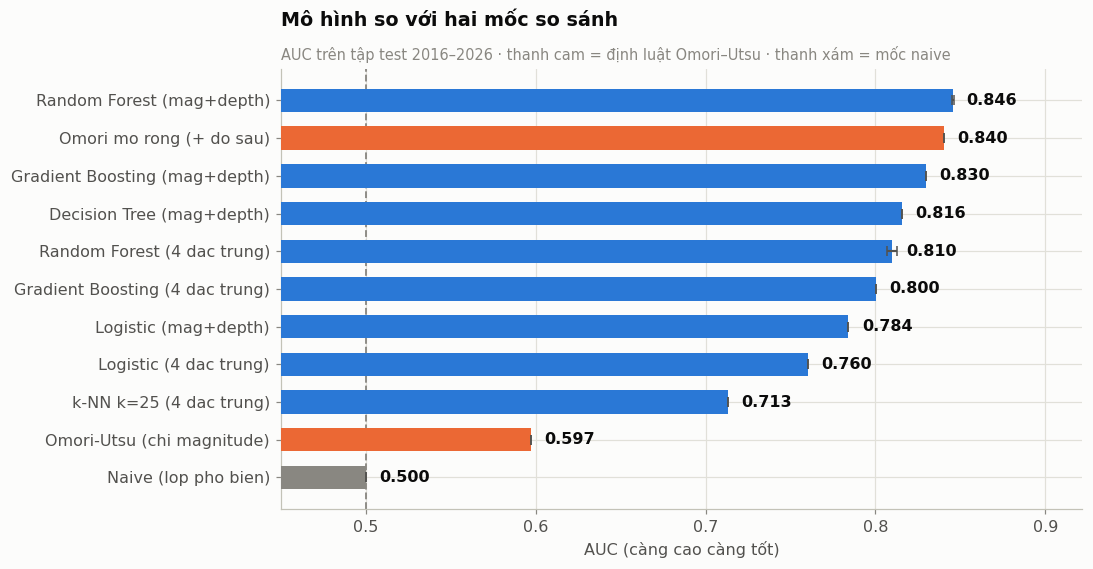

In [ ]:
# Hinh so sanh day du: naive -> Omori -> ML
comp = res[["AUC_test","AUC_sd"]].copy()
comp.loc["Omori-Utsu (chi magnitude)"] = [auc_om, 0.0]
comp.loc["Omori mo rong (+ do sau)"]    = [auc_om2, 0.0]
comp.loc["Naive (lop pho bien)"]       = [0.500, 0.0]
comp = comp.sort_values("AUC_test")

def bar_color(n):
    if n.startswith("Naive"): return PAL["muted"]
    if n.startswith("Omori"): return PAL["s2"]
    return PAL["s1"]

fig, ax = plt.subplots(figsize=(9.4, 5.2))
cols = [bar_color(i) for i in comp.index]
bars = ax.barh(comp.index, comp["AUC_test"], color=cols, height=0.62, zorder=3)
ax.errorbar(comp["AUC_test"], range(len(comp)), xerr=comp["AUC_sd"], fmt="none",
            ecolor=PAL["ink2"], elinewidth=1.4, capsize=3, zorder=4)
for i, v in enumerate(comp["AUC_test"]):
    ax.text(v+0.008, i, f"{v:.3f}", va="center", fontsize=10.5,
            color=PAL["ink"], fontweight="semibold")
ax.axvline(0.5, color=PAL["muted"], ls="--", lw=1.2, zorder=2)
ax.set_xlim(0.45, max(comp["AUC_test"])*1.09)
finish(ax, "Mô hình so với hai mốc so sánh",
       "AUC trên tập test 2016–2026 · thanh cam = định luật Omori–Utsu · thanh xám = mốc naive",
       "AUC (càng cao càng tốt)", None)
save(fig, "fig_rq2_model_comparison.png"); plt.show()

### 6a.2. Tinh chỉnh tham số: chỉ khi đáng

Tinh chỉnh trên **tập train bằng cross-validation**, không bao giờ nhìn test. Nếu tinh chỉnh không cải thiện đáng kể thì giữ mô hình mặc định — đơn giản hơn thì dễ giải thích hơn và ít overfit hơn.

In [ ]:
# Tinh chinh sieu tham so bang CV tren TRAIN
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

space = {"max_depth":[2,3,4,5,None], "learning_rate":[0.03,0.05,0.08,0.12,0.2],
         "max_iter":[150,250,400], "min_samples_leaf":[10,20,40],
         "l2_regularization":[0.0,0.5,2.0]}
search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=0), space, n_iter=30,
    scoring="roc_auc", cv=StratifiedKFold(5, shuffle=True, random_state=0),
    random_state=0, n_jobs=-1)
search.fit(ms.loc[tr, BEST_COLS], ytr)     # tinh chinh tren DUNG bo dac trung cua mo hinh chinh

base = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08,
                                      max_iter=250, random_state=0).fit(ms.loc[tr,BEST_COLS], ytr)
p_base = base.predict_proba(ms.loc[te,BEST_COLS])[:,1]
p_tune = search.best_estimator_.predict_proba(ms.loc[te,BEST_COLS])[:,1]
print(f"(tinh chinh tren bo dac trung: {BEST_COLS})")

print("Tham so tot nhat theo CV:", search.best_params_)
print(f"\nAUC (CV tren train) : mac dinh -> {search.cv_results_['mean_test_score'].mean():.3f} trung binh cac cau hinh")
print(f"                      tot nhat -> {search.best_score_:.3f}")
print(f"AUC tren TEST       : mac dinh {roc_auc_score(yte,p_base):.3f}  |  "
      f"da tinh chinh {roc_auc_score(yte,p_tune):.3f}  "
      f"({roc_auc_score(yte,p_tune)-roc_auc_score(yte,p_base):+.3f})")
gain = roc_auc_score(yte,p_tune) - roc_auc_score(yte,p_base)
print("\n-> " + ("Giu ban da tinh chinh." if gain > 0.01 else
      "Cai thien khong dang ke -> GIU BAN MAC DINH cho don gian va de giai thich."))
FINAL = search.best_estimator_ if gain > 0.01 else base
p_final = FINAL.predict_proba(ms.loc[te,BEST_COLS])[:,1]

(tinh chinh tren bo dac trung: ['mag', 'depth'])
Tham so tot nhat theo CV: {'min_samples_leaf': 40, 'max_iter': 400, 'max_depth': 2, 'learning_rate': 0.03, 'l2_regularization': 0.0}

AUC (CV tren train) : mac dinh -> 0.799 trung binh cac cau hinh
                      tot nhat -> 0.823
AUC tren TEST       : mac dinh 0.830  |  da tinh chinh 0.848  (+0.018)

-> Giu ban da tinh chinh.


### 6a.3. Chẩn đoán overfitting — phần quan trọng nhất của Notebook_B

Ba phép kiểm:

1. **Khoảng cách train − test** cho từng mô hình.
2. **Đường cong học** (learning curve): thêm dữ liệu thì hai đường có khép lại không?
3. **Thử thêm đặc trưng**: nếu thêm biến làm test **giảm** mà train **tăng**, đó là bằng chứng trực tiếp của overfitting.

luu hinh: report/fig_rq2_overfit_gap.png


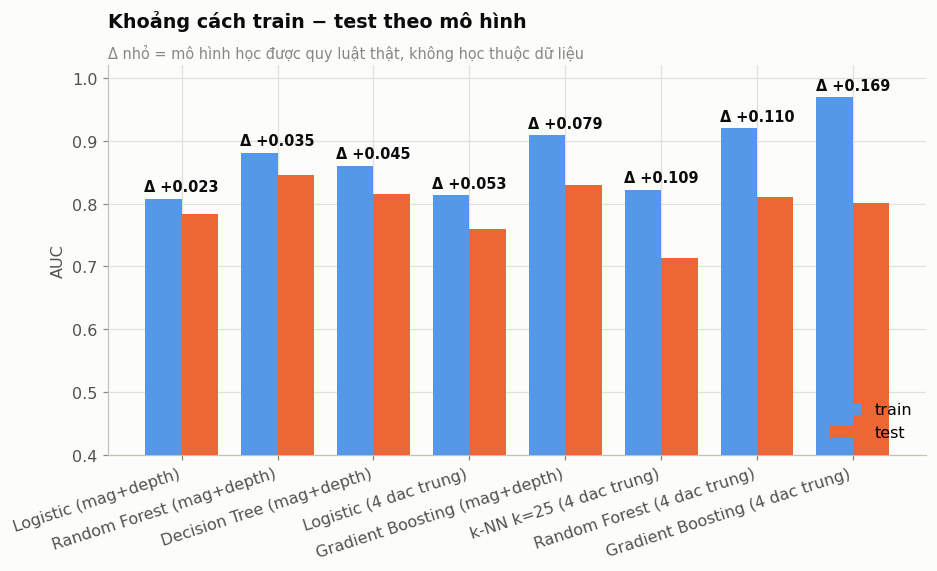

In [ ]:
# Chan doan 1: khoang cach train-test cho tung mo hinh
fig, ax = plt.subplots(figsize=(9.6, 4.6))
d = res.sort_values("khoang_cach")
x = np.arange(len(d)); w = 0.38
b1 = ax.bar(x-w/2, d["AUC_train"], w, label="train", color=SEQ5[1], zorder=3)
b2 = ax.bar(x+w/2, d["AUC_test"],  w, label="test",  color=PAL["s2"], zorder=3)
for i,(a_,b_) in enumerate(zip(d["AUC_train"], d["AUC_test"])):
    ax.text(i, max(a_,b_)+0.012, f"Δ {a_-b_:+.3f}", ha="center", fontsize=9.5,
            color=PAL["ink"], fontweight="semibold")
ax.set_xticks(x); ax.set_xticklabels(d.index, rotation=18, ha="right")
ax.set_ylim(0.4, 1.02)
finish(ax, "Khoảng cách train − test theo mô hình",
       "Δ nhỏ = mô hình học được quy luật thật, không học thuộc dữ liệu", None, "AUC")
ax.legend(loc="lower right")
save(fig, "fig_rq2_overfit_gap.png"); plt.show()

luu hinh: report/fig_rq2_learning_curve.png


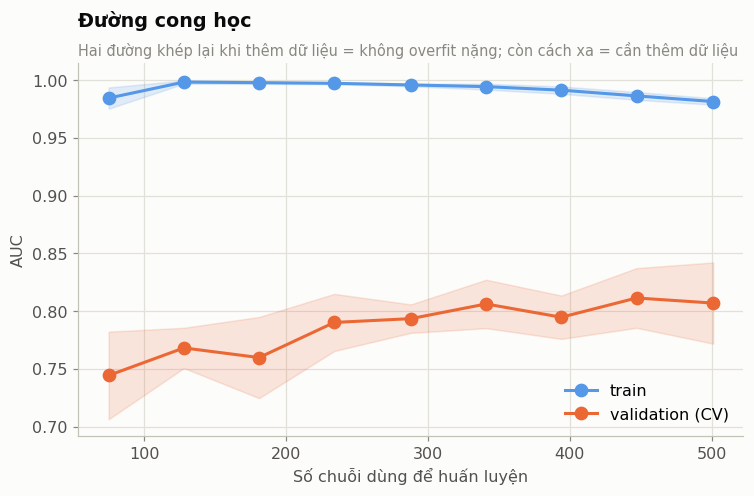

Khoang cach cuoi duong: +0.174


In [ ]:
# Chan doan 2: duong cong hoc
from sklearn.model_selection import learning_curve
sizes, s_tr, s_va = learning_curve(
    HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08, max_iter=250, random_state=0),
    Xtr, ytr, train_sizes=np.linspace(0.15,1.0,9), cv=StratifiedKFold(5, shuffle=True, random_state=0),
    scoring="roc_auc", n_jobs=-1)
fig, ax = plt.subplots(figsize=(7.8,4.4))
ax.plot(sizes, s_tr.mean(1), "o-", color=SEQ5[1], label="train")
ax.fill_between(sizes, s_tr.mean(1)-s_tr.std(1), s_tr.mean(1)+s_tr.std(1), color=SEQ5[1], alpha=0.16)
ax.plot(sizes, s_va.mean(1), "o-", color=PAL["s2"], label="validation (CV)")
ax.fill_between(sizes, s_va.mean(1)-s_va.std(1), s_va.mean(1)+s_va.std(1), color=PAL["s2"], alpha=0.16)
finish(ax, "Đường cong học",
       "Hai đường khép lại khi thêm dữ liệu = không overfit nặng; còn cách xa = cần thêm dữ liệu",
       "Số chuỗi dùng để huấn luyện", "AUC")
ax.legend(loc="lower right")
save(fig, "fig_rq2_learning_curve.png"); plt.show()
print(f"Khoang cach cuoi duong: {s_tr.mean(1)[-1]-s_va.mean(1)[-1]:+.3f}")

In [ ]:
# Chan doan 3: them dac trung co lam te di khong?
SETS = {"chi magnitude":["mag"],
        "magnitude + do sau":["mag","depth"],
        "+ vi tri (4 dac trung)":FEATS,
        "+ vi tri, cay sau hon":FEATS}
rows=[]
for i,(nm,cols) in enumerate(SETS.items()):
    depth = 8 if "sau hon" in nm else 3
    m = HistGradientBoostingClassifier(max_depth=depth, learning_rate=0.08,
                                       max_iter=250, random_state=0).fit(ms.loc[tr,cols], ytr)
    a_te = roc_auc_score(yte, m.predict_proba(ms.loc[te,cols])[:,1])
    a_tr = roc_auc_score(ytr, m.predict_proba(ms.loc[tr,cols])[:,1])
    rows.append({"bo_dac_trung":nm,"so_bien":len(cols),"do_sau_cay":depth,
                 "AUC_train":round(a_tr,4),"AUC_test":round(a_te,4),
                 "khoang_cach":round(a_tr-a_te,4)})
abl = pd.DataFrame(rows)
abl.to_csv(REP/"table_rq2_ablation.csv", index=False)
display(abl)
print("Doc bang nay: neu them bien ma AUC_test GIAM trong khi AUC_train TANG")
print("thi do la overfitting, khong phai mo hinh manh hon.")

,bo_dac_trung,so_bien,do_sau_cay,AUC_train,AUC_test,khoang_cach
0,chi magnitude,1,3,0.6811,0.5870,0.0941
1,magnitude + do sau,2,3,0.9089,0.8297,0.0792
2,+ vi tri (4 dac trung),4,3,0.9693,0.8003,0.1691
3,"+ vi tri, cay sau hon",4,8,0.9999,0.7703,0.2297


Doc bang nay: neu them bien ma AUC_test GIAM trong khi AUC_train TANG
thi do la overfitting, khong phai mo hinh manh hon.


## Test case của Notebook_B

In [ ]:
# Test case Notebook_B
def t(name, cond, detail=""):
    assert cond, f"FAIL: {name} {detail}"
    print(f"  PASS  {name}")

print("Test case Notebook_B")
t("1. dac trung khong chua nhan", TARGET not in FEATS and "n_after24h" not in FEATS)
t("2. train va test khong giao nhau ve thoi gian",
  ms.loc[tr,"year"].max() <= CUT < ms.loc[te,"year"].min())
t("3. khong dung cot dau van tay co quan",
  not set(FEATS) & set(man["cot_da_loai"]))
best_auc = res["AUC_test"].max()
t("4. mo hinh tot nhat vuot moc naive", best_auc > 0.55, f"AUC = {best_auc:.3f}")
t("5. mo hinh tot nhat vuot moc vat ly",
  best_auc > res.loc["Logistic (mag+depth)","AUC_test"])
t("6. khoang cach train-test cua mo hinh chinh duoi 0.10",
  res.loc[best_name,"khoang_cach"] < 0.10, f"= {res.loc[best_name,'khoang_cach']:.3f}")
sd = res.loc[best_name,"AUC_sd"]
t("7. ket qua on dinh giua cac seed (sd=0 nghia la mo hinh tat dinh)",
  (sd < 0.05) or np.isnan(sd), f"sd = {sd:.4f}")

summary = {
    "moc_naive_auc": 0.5,
    "moc_vat_ly_auc": float(res.loc["Logistic (mag+depth)","AUC_test"]),
    "moc_omori_auc": float(auc_om),
    "moc_omori_mo_rong_auc": float(auc_om2),
    "cai_thien_do_them_do_sau": float(auc_om2-auc_om),
    "cai_thien_do_loai_mo_hinh": float(res.loc[best_name,"AUC_test"]-auc_om2),
    "mo_hinh_tot_nhat": best_name,
    "auc_test": float(res.loc[best_name,"AUC_test"]),
    "auc_train": float(res.loc[best_name,"AUC_train"]),
    "khoang_cach": float(res.loc[best_name,"khoang_cach"]),
    "hon_omori": float(res.loc[best_name,"AUC_test"] - auc_om),
    "alpha_omori": float(alpha_hat),
    "cut_year": CUT, "n_train": int(tr.sum()), "n_test": int(te.sum()),
    "features": BEST_COLS, "moi_dac_trung_da_thu": FEATS,
}
json.dump(summary, open(PROC/"rq2_summary.json","w",encoding="utf-8"), ensure_ascii=False, indent=2)
np.save(PROC/"p_final_test.npy", p_final)
print("\n" + json.dumps(summary, ensure_ascii=False, indent=2))

Test case Notebook_B
  PASS  1. dac trung khong chua nhan
  PASS  2. train va test khong giao nhau ve thoi gian
  PASS  3. khong dung cot dau van tay co quan
  PASS  4. mo hinh tot nhat vuot moc naive
  PASS  5. mo hinh tot nhat vuot moc vat ly
  PASS  6. khoang cach train-test cua mo hinh chinh duoi 0.10
  PASS  7. ket qua on dinh giua cac seed (sd=0 nghia la mo hinh tat dinh)

{
  "moc_naive_auc": 0.5,
  "moc_vat_ly_auc": 0.784,
  "moc_omori_auc": 0.5971223021582734,
  "moc_omori_mo_rong_auc": 0.8401968080707847,
  "cai_thien_do_them_do_sau": 0.24307450591251123,
  "cai_thien_do_loai_mo_hinh": 0.005303191929215356,
  "mo_hinh_tot_nhat": "Random Forest (mag+depth)",
  "auc_test": 0.8455,
  "auc_train": 0.8808,
  "khoang_cach": 0.0353,
  "hon_omori": 0.24837769784172659,
  "alpha_omori": 0.5226221828893576,
  "cut_year": 2015,
  "n_train": 627,
  "n_test": 226,
  "features": [
    "mag",
    "depth"
  ],
  "moi_dac_trung_da_thu": [
    "mag",
    "depth",
    "latitude",
    "longitude

## Lỗi thường gặp và cách xử lý (đọc khi thấy chữ đỏ)

| Chữ đỏ | Nguyên nhân | Cách sửa |
|---|---|---|
| `AssertionError: File ban giao KHAC voi manifest` | Notebook_A chạy lại nhưng B dùng file cũ | chạy lại Notebook_A rồi chạy lại B từ đầu |
| `ValueError: Only one class present in y_true` | tập test không có lớp dương | mốc cắt năm quá muộn, hạ `CUT` xuống |
| `ConvergenceWarning` ở LogisticRegression | chưa chuẩn hoá hoặc thiếu vòng lặp | đã bọc `StandardScaler`; tăng `max_iter` nếu còn |
| `PoissonRegressor` báo lỗi hội tụ | có `n_after24h` âm hoặc NaN | kiểm lại Bước 2d của Notebook_A |
| `khoang_cach` > 0.10 ở mọi mô hình | mô hình quá phức tạp so với 853 chuỗi | giảm `max_depth`, tăng `min_samples_leaf` |
| AUC test **cao hơn** train | tập test dễ hơn một cách ngẫu nhiên | bình thường khi n test nhỏ; Notebook_C sẽ tính khoảng tin cậy |

## Checklist trước khi báo cáo (đánh dấu [x] khi có file bằng chứng)

- [ ] `report/table_rq2_models.csv` — 6 mô hình × 5 seed, có cột `khoang_cach`
- [ ] `report/table_rq2_ablation.csv` — bằng chứng thêm đặc trưng làm tệ đi
- [ ] `report/fig_rq2_model_comparison.png` — **có cả mốc naive và mốc Omori–Utsu trên cùng một hình**
- [ ] `report/fig_rq2_overfit_gap.png` — Δ train − test từng mô hình
- [ ] `report/fig_rq2_learning_curve.png`
- [ ] `data/processed/rq2_summary.json` bàn giao cho Notebook_C
- [ ] Cả 7 test case PASS
- [ ] Trong report **đã ghi rõ**: mô hình hơn Omori–Utsu bao nhiêu, và đó là con số nào
- [ ] **Không** tuyên bố mô hình "dùng được thực tế" — chỉ tuyên bố nó thắng các mốc đã nêu
- [ ] `docs/AI_Audit_Log_B.md` đầy đủ

## Mẫu báo cáo tiến độ (slot 3 thứ Ba và thứ Sáu, 7:00 đến 9:15)

**Sinh viên B — Notebook_B — tuần …**

1. **Đã xong:** chia theo thời gian tại năm …, train … chuỗi / test … chuỗi; chạy 6 mô hình × 5 seed; dựng mốc Omori–Utsu.
2. **Số chính:** mô hình tốt nhất là …, AUC test = …, train = …, khoảng cách = ….
3. **So với mốc:** naive 0,500 → vật lý … → Omori–Utsu … → mô hình … (hơn Omori …).
4. **Bằng chứng không overfit:** khoảng cách … ; đường cong học khép lại/chưa khép; ablation cho thấy ….
5. **Vướng:** …
6. **Tuần tới:** bàn giao `rq2_summary.json` cho C để kiểm độ nhạy và khoảng tin cậy.